# Run Segment Anything Model 2 on a live video stream


In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from IPython import display
import networkx as nx
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import re

In [2]:
# use bfloat16 for the entire notebook
torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()

if torch.cuda.get_device_properties(0).major >= 8:
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

### Loading the SAM 2 camera predictor


In [3]:
from sam2.build_sam import build_sam2_camera_predictor

sam2_checkpoint = "../checkpoints/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

predictor = build_sam2_camera_predictor(model_cfg, sam2_checkpoint) # in multiple object tracking we have initialise interference state

In [4]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(
        pos_points[:, 0],
        pos_points[:, 1],
        color="green",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )
    ax.scatter(
        neg_points[:, 0],
        neg_points[:, 1],
        color="red",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )


def show_bbox(bbox, ax, marker_size=200):
    tl, br = bbox[0], bbox[1]
    w, h = (br - tl)[0], (br - tl)[1]
    x, y = tl[0], tl[1]
    print(x, y, w, h)
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=None, edgecolor="blue", linewidth=2))

In [5]:
def gen_out_mask_logits_ids(ann_frame_idx=0, ann_obj_id=1, points=None,  bbox=None, mask=None, labels=None):
    if points is not None:
        if labels is None:
            raise ValueError("Labels must be provided if points are given.")
        else:
            _, out_obj_ids, out_mask_logits = predictor.add_new_prompt(
                frame_idx=ann_frame_idx,
                obj_id=ann_obj_id,
                points=points,
                labels=labels,
            )
            # show_points(points, labels, plt.gca())

    elif bbox is not None:
        # TODO need to add multiple prompt per track
        _, out_obj_ids, out_mask_logits = predictor.add_new_prompt(
            frame_idx=ann_frame_idx, obj_id=ann_obj_id, bbox=bbox)
        # show_bbox(bbox, plt.gca())

    elif mask is not None:
        # mask_img_path="masks/aquarium/aquarium_mask.png"
        # mask = cv2.imread(mask_img_path, cv2.IMREAD_GRAYSCALE)
        # mask = mask / 255
        assert mask.max() <= 1 , "Masks should be in [0, 1] range."
        _, out_obj_ids, out_mask_logits = predictor.add_new_mask(
            frame_idx=ann_frame_idx, obj_id=ann_obj_id, mask=mask
        )
        # show_mask(out_mask_logits, plt.gca(), obj_id=ann_obj_id, random_color=True)
    else:
        raise ValueError("At least one of points, bbox, or mask must be provided.")
    
    return out_obj_ids, out_mask_logits

#### Select an video stream (video or camera)


In [6]:
cap = cv2.VideoCapture("videos/aquarium/aquarium.mp4")
cap = cv2.VideoCapture("/scratch3/kat049/datasets/DARPA/p14_fr/camera0-1024x768-002.mp4")
ret, frame = cap.read()
width, height = frame.shape[:2][::-1]

start_idx = 1148
vis_gap = 30
video_dir = "/scratch3/kat049/datasets/DARPA/p14_fr/results" #args.video_path
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(p[len("frame"):].split('.')[0]))
frame_names = frame_names[start_idx:-1:vis_gap]
frame = Image.open(os.path.join(video_dir, frame_names[0])) #image_pil
frame_RGB = np.array(frame) #image_rgb
frame_BGR = frame_RGB[:, :, ::-1]  # image
width, height = frame.size[0], frame.size[1]

#### Step 1: Add a first click on the first frame


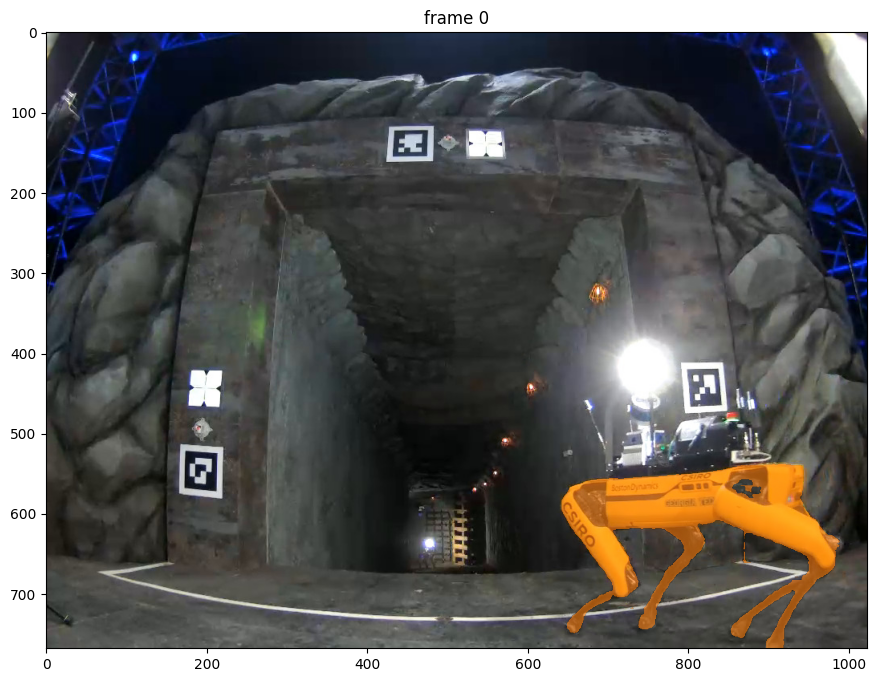

In [7]:
predictor.load_first_frame(frame_BGR)
# if_init = True

# using_point = False # if True, we use point prompt
# using_box = True # if True, we use point prompt
# using_mask= False  # if True, we use mask prompt

ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = (
    1  # give a unique id to each object we interact with (it can be any integers)
)
# Let's add a positive click at (x, y) = (210, 350) to get started

# using point prompt
points = np.array([[670, 247]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([1], dtype=np.int32)
bbox = np.array([[600, 214], [765, 286]], dtype=np.float32)
bbox = np.array([[440, 580], [500, 680]], dtype=np.float32)
bbox1 = np.array([[620, 540], [980, 800]], dtype=np.float32)
# bbox2 = np.array([[160, 510], [220, 580]], dtype=np.float32)


# # TODO need to implement multiple prompt per track
# bboxes = [bbox1, bbox2]
# for ann_obj_id in range(2):
#     print(f"Adding prompt for object {ann_obj_id+1} in frame {ann_frame_idx} with bbox {bboxes[ann_obj_id]}")
#     # frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#     plt.figure(figsize=(12, 8))
#     plt.title(f"frame {ann_frame_idx}")
#     plt.imshow(frame_RGB)
#     bbox = bboxes[ann_obj_id]
#     out_obj_ids, out_mask_logits = gen_out_mask_logits_ids(
#         ann_frame_idx=ann_frame_idx,
#         ann_obj_id=ann_obj_id+1,
#         points=None,
#         labels=None,
#         bbox=bbox,
#         mask=None,
#     )
#     show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=ann_obj_id+1)
#     plt.show()
#     plt.close()

# frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(frame_RGB)
out_obj_ids, out_mask_logits = gen_out_mask_logits_ids(
    ann_frame_idx=ann_frame_idx,
    ann_obj_id=ann_obj_id,
    points=None,
    labels=None,
    bbox=bbox1,
    mask=None,
)
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=ann_obj_id)
plt.show()


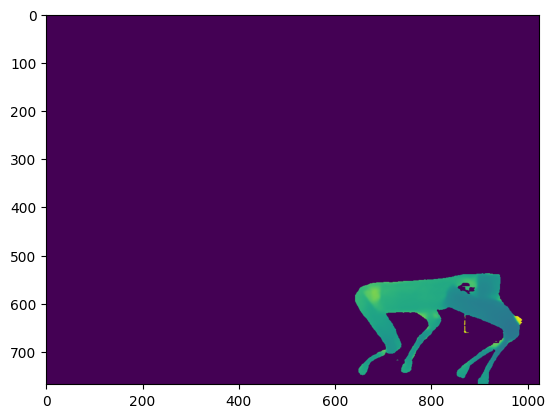

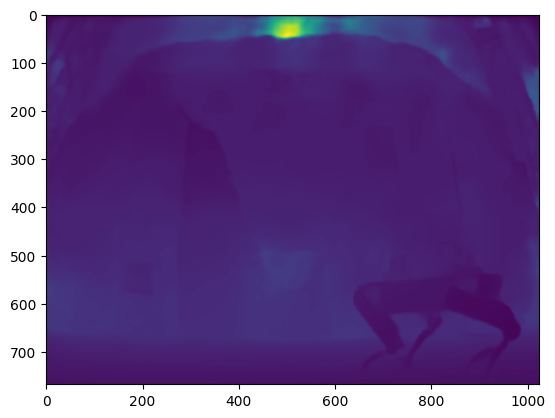

5.5566872775532365

In [8]:
# depth_names = [
#     p for p in os.listdir(video_dir)
#     if os.path.splitext(p)[-1] in [".png"]
# ]
# depth_names.sort(key=lambda p: int(p[len("depth"):].split('.')[0]))
# depth_names = depth_names[start_idx:-1:vis_gap]

depth_frame = Image.open(os.path.join(video_dir, re.sub(r'frame(\d+)\.jpg', r'depth\1.png', frame_names[0]))) #image_pil
depth_frame = np.array(depth_frame)

mask = (out_mask_logits.squeeze() > 0).cpu().numpy()  # Shape: (768, 1024)
masked_depth_image = depth_frame * mask  # Shape: (768, 1024)
masked_depths = depth_frame[mask]
plt.imshow(masked_depth_image)
plt.show()
plt.imshow(depth_frame)
plt.show()
mean_depth = np.mean(masked_depths)/1000 # Convert to meters
mean_depth

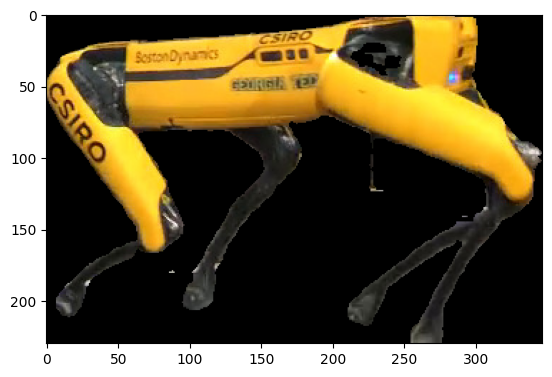

In [9]:
# get the masked image
masked_image = torch.tensor(frame_RGB.copy(), device="cuda").permute(2, 0, 1)  # [3, 360, 800]
# masked_rgb_image = frame_RGB * mask[..., None] 
# bbox = bbox1
# x_min, y_min = int(bbox[0][0]), int(bbox[0][1])
# x_max, y_max = int(bbox[1][0]), int(bbox[1][1])
# x_min = max(0, min(x_min, width-1))
# y_min = max(0, min(y_min, height-1))
# x_max = max(0, min(x_max, width-1))
# y_max = max(0, min(y_max, height-1))
# bbox_region = masked_image[:, y_min:y_max, x_min:x_max]
# bbox_region_np = bbox_region.permute(1, 2, 0).cpu().numpy()

rows = np.any(mask, axis=1)
cols = np.any(mask, axis=0)
y_min, y_max = np.where(rows)[0][[0, -1]]
x_min, x_max = np.where(cols)[0][[0, -1]]

# Crop both RGB and mask to bounding box
cropped_rgb = frame_RGB[y_min:y_max+1, x_min:x_max+1]
cropped_mask = mask[y_min:y_max+1, x_min:x_max+1]

masked_rgb_cropped = cropped_rgb * cropped_mask[:, :, None]
plt.imshow(masked_rgb_cropped)

In [ ]:
def create_mixed_graph(image_node, rel_distance):
    """Create a graph with mixed node types"""
    G = nx.Graph()
    
    # Add nodes with different types
    G.add_node("text1", type="text", content="Self", pos=(0, 0))
    G.add_node("mask1", type="mask", content=image_node, pos=(1, 1))
    
    # Add edges
    G.add_edges_from([
        ("text1", "mask1", {"weight": rel_distance}),
    ])
    
    return G

def visualize_mixed_graph(G, ax):
    """Visualize graph with text and image nodes"""    
    # Get positions
    pos = nx.get_node_attributes(G, 'pos')

    # Draw edges with weights
    edges = G.edges(data=True)
    edge_weights = [d.get('weight', 1.0) for u, v, d in edges]
    
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', width=2)
    
    # Draw edge labels (weights)
    edge_labels = {(u, v): f"{d.get('weight', 1.0):.1f}" for u, v, d in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax, font_size=8)
    
    # Process each node
    for node, (x, y) in pos.items():
        node_data = G.nodes[node]
        
        if node_data['type'] == 'text':
            # Draw text nodes as boxes
            bbox = dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.8)
            ax.text(x, y, node_data['content'], ha='center', va='center', 
                   fontsize=12, bbox=bbox, weight='bold')
                   
        elif node_data['type'] == 'mask':
            # Draw mask nodes as images
            mask_img = node_data['content']
            # Handle different mask formats
            if len(mask_img.shape) == 2:
                # Grayscale mask [h, w] -> RGB
                mask_rgb = cv2.cvtColor(mask_img, cv2.COLOR_GRAY2RGB)
            elif mask_img.shape[2] == 3:
                # Already RGB [h, w, 3]
                mask_rgb = mask_img
            else:
                # Handle other cases (like RGBA)
                mask_rgb = mask_img[:, :, :3]
                
            # Create OffsetImage
            imagebox = OffsetImage(mask_rgb, zoom=0.5)
            ab = AnnotationBbox(imagebox, (x, y), frameon=True, pad=0.1)
            ax.add_artist(ab)
    
    # ax.set_xlim(-1, 3)
    # ax.set_ylim(-2, 2)
    # ax.set_aspect('equal')
    # ax.set_title('Graph at time', fontsize=14, weight='bold')
    ax.axis('off')
    
    # plt.tight_layout()
    # return ax

G_temporal = []
G = create_mixed_graph(masked_rgb_cropped,mean_depth)
G_temporal.append(G)

In [17]:
# fig, ax = plt.subplots(figsize=(12, 8))
# visualize_mixed_graph(G, ax)
# plt.show()
# plt.close(fig)
for i, file in enumerate(frame_names[1:]):
    if i > 30:
        break
    frame = Image.open(os.path.join(video_dir, file)) #image_pil
    frame_RGB = np.array(frame) #image_rgb
    frame_BGR = frame_RGB[:, :, ::-1]  # image

    out_obj_ids, out_mask_logits = predictor.track(frame_BGR)

    depth_frame = Image.open(os.path.join(video_dir, re.sub(r'frame(\d+)\.jpg', r'depth\1.png', file))) #image_pil
    depth_frame = np.array(depth_frame)

    mask = (out_mask_logits.squeeze() > 0).cpu().numpy()  # Shape: (768, 1024)
    masked_depth_image = depth_frame * mask  # Shape: (768, 1024)
    masked_depths = depth_frame[mask]
    # plt.imshow(masked_depth_image)
    # plt.show()
    # plt.imshow(depth_frame)
    # plt.show()
    mean_depth = np.mean(masked_depths)/1000 # Convert to meters
    # print(mean_depth)

    masked_image = torch.tensor(frame_RGB.copy(), device="cuda").permute(2, 0, 1)  # [3, h, w]
    print(i, (mask==True).any())
    if not (mask==True).any():
        print("No mask found, skipping frame")
        continue
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]

    # Crop both RGB and mask to bounding box
    cropped_rgb = frame_RGB[y_min:y_max+1, x_min:x_max+1]
    cropped_mask = mask[y_min:y_max+1, x_min:x_max+1]

    masked_rgb_cropped = cropped_rgb * cropped_mask[:, :, None]
    # plt.imshow(masked_rgb_cropped)

    G = create_mixed_graph(masked_rgb_cropped,mean_depth)
    G_temporal.append(G)
    # fig, ax = plt.subplots(figsize=(12, 8))
    # visualize_mixed_graph(G, ax)
    # plt.show()
    # plt.close(fig)

0 True
1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True
16 True
17 True
18 True
19 True
20 True
21 False
No mask found, skipping frame
22 False
No mask found, skipping frame


/scratch3/kat049/segment-anything-2-real-time/.venv2/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/scratch3/kat049/segment-anything-2-real-time/.venv2/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


23 False
No mask found, skipping frame
24 False
No mask found, skipping frame
25 False
No mask found, skipping frame
26 False
No mask found, skipping frame
27 False
No mask found, skipping frame
28 False
No mask found, skipping frame
29 False
No mask found, skipping frame
30 False
No mask found, skipping frame


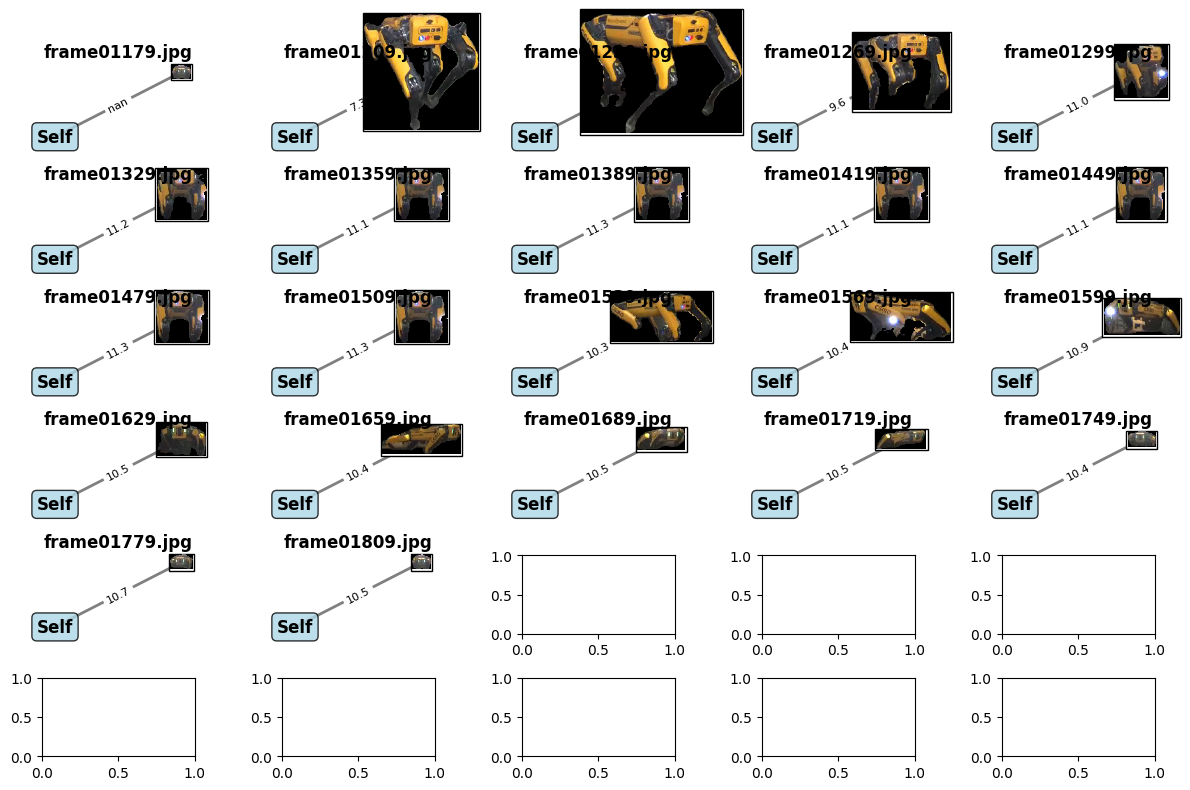

In [19]:
fig, axes  = plt.subplots(6, 5, figsize=(12, 8))
ax_iter = iter(axes.flat)


for i, g in enumerate(G_temporal):
    file = frame_names[1:][i]
    try:
        ax = next(ax_iter)
        visualize_mixed_graph(g, ax=ax)
        ax.set_title(f'{file}', fontsize=12, weight='bold')
    except StopIteration:
        print(f"Warning: More graphs ({len(G_temporal)}) than subplots (12)")
        break

# Hide unused subplots
for j in range(i+1, 12):
    axes.flat[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
vis_gap = 30
fps = cap.get(cv2.CAP_PROP_FPS)
rendered_frames = []

while True:
    ret, frame = cap.read()
    ann_frame_idx += 1
    if not ret:
        break
    width, height = frame.shape[:2][::-1]

    out_obj_ids, out_mask_logits = predictor.track(frame)

    if ann_frame_idx % vis_gap == 0:
        # print(f"frame {ann_frame_idx}")
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.set_title(f"frame {ann_frame_idx}")
        ax.imshow(frame)
        show_mask(
            (out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0]
        )
        fig.canvas.draw()
        image = np.array(fig.canvas.renderer.buffer_rgba())
        plt.close(fig)
        rendered_frames.append(image)

cap.release()


In [ ]:
import imageio
imageio.mimsave("output_video.mp4", rendered_frames, fps=10)

#### Step 2: track


In [1]:
# vis_gap = 30

# while True:

#     ret, frame = cap.read()
#     ann_frame_idx += 1
#     if not ret:
#         break
#     width, height = frame.shape[:2][::-1]

#     out_obj_ids, out_mask_logits = predictor.track(frame)

#     if ann_frame_idx % vis_gap == 0:
#         print(f"frame {ann_frame_idx}")
#         frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         display.clear_output(wait=True)
#         plt.figure(figsize=(12, 8))
#         plt.title(f"frame {ann_frame_idx}")
#         plt.imshow(frame)
#         show_mask(
#             (out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0]
#         )

# cap.release()

## Doing some stuff 

In [ ]:
predictor = build_sam2_camera_predictor(model_cfg, sam2_checkpoint)

ann_frame_idx = 0
# cap = cv2.VideoCapture("videos/aquarium/aquarium.mp4")
cap = cv2.VideoCapture("/scratch3/kat049/datasets/DARPA/p14_fr/camera0-1024x768-002.mp4")

ret, frame = cap.read()
width, height = frame.shape[:2][::-1]
# bbox = np.array([[600, 214], [765, 286]], dtype=np.float32)
bbox = np.array([[440, 580], [500, 680]], dtype=np.float32)

predictor.load_first_frame(frame)
if_init = True

using_point = False # if True, we use point prompt
using_box = True # if True, we use point prompt
using_mask= False  # if True, we use mask prompt

ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = (
    2  # give a unique id to each object we interact with (it can be any integers)
)
# Let's add a positive click at (x, y) = (210, 350) to get started


frame_RGB = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(frame_RGB)

if using_point:
    _, out_obj_ids, out_mask_logits = predictor.add_new_prompt(
        frame_idx=ann_frame_idx,
        obj_id=ann_obj_id,
        points=points,
        labels=labels,
    )
    show_points(points, labels, plt.gca())

elif using_box:
    _, out_obj_ids, out_mask_logits = predictor.add_new_prompt(
        frame_idx=ann_frame_idx, obj_id=ann_obj_id, bbox=bbox
    )
    show_bbox(bbox, plt.gca())

elif using_mask:
    mask_img_path="masks/aquarium/aquarium_mask.png"
    mask = cv2.imread(mask_img_path, cv2.IMREAD_GRAYSCALE)
    mask = mask / 255

    _, out_obj_ids, out_mask_logits = predictor.add_new_mask(
        frame_idx=ann_frame_idx, obj_id=ann_obj_id, mask=mask
    )
    

show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

In [ ]:
plt.close()
plt.figure(figsize=(12, 8))
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

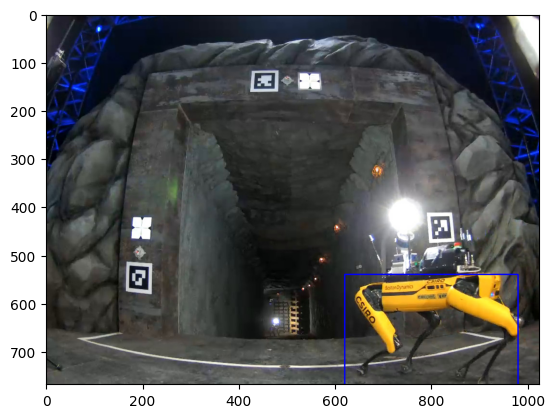

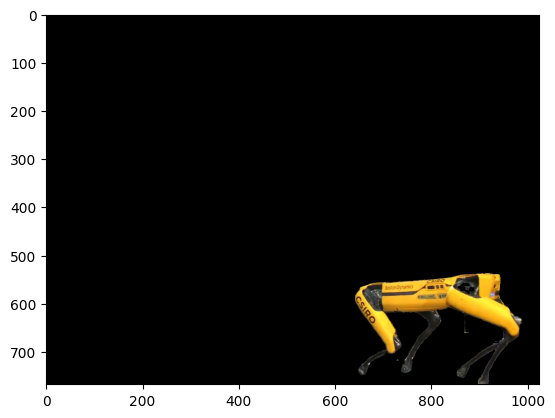

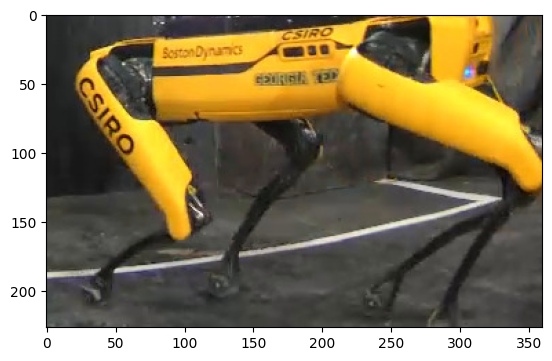

(torch.Size([3, 768, 1024]), torch.Size([3, 227, 360]))

In [24]:
def get_image_with_bbox_as_tensor(frame, bbox, device="cuda", color=(0, 0, 255), thickness=2):
    # Make a copy of the frame to avoid modifying the original
    img_with_bbox = frame.copy()
    
    # Draw the bounding box directly on the image
    tl, br = bbox[0].astype(int), bbox[1].astype(int)
    x1, y1 = tl[0], tl[1]
    x2, y2 = br[0], br[1]
    
    # Draw rectangle (Note: OpenCV uses (B,G,R) color format)
    # If frame is already in RGB, you might need to adjust the color
    cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), color, thickness)
    
    # Convert to torch tensor
    img_tensor = torch.tensor(img_with_bbox, device=device).permute(2, 0, 1)  # [3, H, W]
    
    return img_tensor

# Step 1: Convert logits to boolean mask (threshold at 0, or use your own logic)
mask = out_mask_logits > 0  # [1, 1, 360, 800]
mask = mask.squeeze(0).squeeze(0)  # [360, 800]

# Step 2: Expand mask to RGB shape
mask_rgb = mask.unsqueeze(0).repeat(3, 1, 1)  # [3, 360, 800]

# Step 3: Apply the mask to the image
masked_image = torch.tensor(frame_RGB.copy(), device="cuda").permute(2, 0, 1)  # [3, 360, 800]

bbox = bbox1
x_min, y_min = int(bbox[0][0]), int(bbox[0][1])
x_max, y_max = int(bbox[1][0]), int(bbox[1][1])
# Check if the coordinates are within the image boundaries
x_min = max(0, min(x_min, width-1))
y_min = max(0, min(y_min, height-1))
x_max = max(0, min(x_max, width-1))
y_max = max(0, min(y_max, height-1))
# Extract the region - note the ordering for PyTorch tensors [channels, height, width]
# Assuming masked_image is [3, 360, 800]
bbox_region = masked_image[:, y_min:y_max, x_min:x_max]
# If you want to visualize or save this region, you might need to convert back to numpy
bbox_region_np = bbox_region.permute(1, 2, 0).cpu().numpy()

img_tensor = get_image_with_bbox_as_tensor(frame_RGB, bbox)
plt.imshow(img_tensor.permute(1, 2, 0).cpu().numpy())
plt.show()

masked_image[~mask_rgb] = 0  # Make non-mask regions black
plt.imshow(masked_image.cpu().permute(1, 2, 0))
plt.show()


plt.imshow(bbox_region_np)
plt.show()
masked_image.shape, bbox_region.shape

In [ ]:
# Aria
import requests
import torch
from PIL import Image

# from transformers import BlipProcessor, BlipForQuestionAnswering
# processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base", use_fast=True)
# model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to("cuda")

# from transformers import ViltProcessor, ViltForQuestionAnswering
# processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa", use_fast=True)
# model = ViltForQuestionAnswering.from_pretrained("dandelin/vilt-b32-finetuned-vqa")

from transformers import AriaProcessor, AriaForConditionalGeneration
model_id_or_path = "rhymes-ai/Aria"
model = AriaForConditionalGeneration.from_pretrained(
    model_id_or_path, device_map="auto", torch_dtype=torch.bfloat16
)
processor = AriaProcessor.from_pretrained(model_id_or_path)


In [ ]:
question_1 = """You are an expert image analyst specializing in object recognition. I will provide you with an image where a specific area is highlighted by a blue box surrounding the object of interest.
For the highlighted area, please:

Identify what object is contained within the highlighted region with high specificity (e.g., "office chair" rather than just "chair")
Determine if this object is likely STATIC (fixed in place, rarely moves) or DYNAMIC (regularly moves or is designed to be moved)
Provide a brief explanation for your static/dynamic classification

Format your response exactly as follows:
OBJECT: [specific name of identified object]
MOBILITY: [STATIC or DYNAMIC]
REASON: [1-2 sentence explanation for mobility classification]

Consider both the object's design purpose and its practical usage patterns when determining mobility. If uncertain about mobility, note your confidence level in your explanation.
"""
# image = img_tensor

# good question
# question_2 = "What is this an image of? What you see is a masked part of an image. Give a title of the object you see. Look at the surrounding area if you need more context."
question_2 = """You are an expert image analyst specializing in object recognition. I will provide you with a masked image where only the object of interest is visible, and the rest of the image is removed or obscured.
For each masked object, please:

Identify what object is shown in the masked region with high specificity (e.g., "office chair" rather than just "chair")
Determine if this object is likely STATIC (fixed in place, rarely moves) or DYNAMIC (regularly moves or is designed to be moved)
Provide a brief explanation for your static/dynamic classification

Format your response exactly as follows:
OBJECT: [specific name of identified object]
MOBILITY: [STATIC or DYNAMIC]
REASON: [1-2 sentence explanation for mobility classification]

Consider both the object's design purpose and its practical usage patterns when determining mobility. If uncertain about mobility, note your confidence level in your explanation.
Note that with masked images, you may have less contextual information about the object's surroundings. If the masking makes identification difficult or ambiguous, please state this in your response and provide your best assessment based on the visible features.
"""
# image = bbox_region 
# image = masked_image 

for i, (img, q) in enumerate(zip([img_tensor, bbox_region], [question_1, question_2])):
    print(f"Round {i+1}")
    image = img
    question = q
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"text": f"{question}", "type": "text"},
            ],
        }
    ]

    text = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=text, images=image, return_tensors="pt")
    inputs['pixel_values'] = inputs['pixel_values'].to(torch.bfloat16)
    inputs.to(model.device)

    output = model.generate(
        **inputs,
        max_new_tokens=100,
        stop_strings=["<|im_end|>"],
        tokenizer=processor.tokenizer,
        do_sample=True,
        temperature=0.1,#0.9
    )
    output_ids = output[0][inputs["input_ids"].shape[1]:]
    response = processor.decode(output_ids, skip_special_tokens=True)
    print(response)

### Auto-SAM based implementation

In [5]:
pred_iou_thresh = 0.7
box_nms_thresh = 0.7
stability_score_thresh = 0.85
level = "large"
postnms = 1
use_other_level = 1
batch_size = 1
base_dir = "/scratch3/kat049/segment-anything-2-real-time/output"

import sys
from tqdm import tqdm
sys.path.append('/scratch3/kat049/AutoSeg-SAM2/submodule/segment-anything-1')
from segment_anything.automatic_mask_generator import SamAutomaticMaskGenerator
from segment_anything.build_sam import sam_model_registry
import sys
sys.path.append('/scratch3/kat049/AutoSeg-SAM2')
import importlib.util
spec = importlib.util.spec_from_file_location("auto_mask_batch", "/scratch3/kat049/AutoSeg-SAM2/auto-mask-batch.py")
auto_mask_batch = importlib.util.module_from_spec(spec)
spec.loader.exec_module(auto_mask_batch)

sam_ckpt_path="/scratch3/kat049/AutoSeg-SAM2/checkpoints/sam1/sam_vit_h_4b8939.pth"
sam = sam_model_registry["vit_h"](checkpoint=sam_ckpt_path).to('cuda')

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=pred_iou_thresh, 
    box_nms_thresh=box_nms_thresh, 
    stability_score_thresh=stability_score_thresh, 
    crop_n_layers=1,
    crop_n_points_downscale_factor=1,
    min_mask_region_area=100,
)

In [6]:
masks_from_prev = []
sum_id = 0 
ann_frame_idx = 0

### Generic parts

In [8]:
cap = cv2.VideoCapture("videos/aquarium/aquarium.mp4")
cap = cv2.VideoCapture("/scratch3/kat049/datasets/DARPA/p14_fr/camera0-1024x768-002.mp4")
ret, frame = cap.read()
from PIL import Image
video_dir = "/scratch3/kat049/VSLAM-LAB-Benchmark/DARPA/p14_fr_2/rgb" #args.video_path
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(p[len("frame"):].split('.')[0]))
frame_names = frame_names[0:-1:30]

frame = Image.open(os.path.join(video_dir, frame_names[0]))
frame_RGB = np.array(frame)
width, height = frame.size[0], frame.size[1]
predictor.load_first_frame(frame)

prompts_loader = auto_mask_batch.Prompts(bs=batch_size)
gap = 0

In [9]:
masks_default, masks_s, masks_m, masks_l = mask_generator.generate(frame_RGB)
if postnms:
    masks_default, masks_s, masks_m, masks_l = \
        auto_mask_batch.masks_update(masks_default, masks_s, masks_m, masks_l, iou_thr=0.8, score_thr=0.7, inner_thr=0.5)
if level == 'default':
    masks = [mask for mask in masks_default]
    other_masks = [mask for mask in masks_l] + [mask for mask in masks_m] + [mask for mask in masks_s] 
elif level == 'small':
    masks = [mask for mask in masks_s]
    other_masks = None
elif level == 'middle':
    masks = [mask for mask in masks_m]
    other_masks = [mask for mask in masks_s]
elif level == 'large':
    masks = [mask for mask in masks_l]
    other_masks = [mask for mask in masks_s] + [mask for mask in masks_m]
else:
    raise NotImplementedError
if not use_other_level:
    other_masks = None

OutOfMemoryError: CUDA out of memory. Tried to allocate 1024.00 MiB. GPU 0 has a total capacity of 93.23 GiB of which 298.06 MiB is free. Process 69100 has 932.00 MiB memory in use. Process 70165 has 15.03 GiB memory in use. Process 10224 has 802.00 MiB memory in use. Process 57238 has 898.00 MiB memory in use. Process 41291 has 898.00 MiB memory in use. Process 64920 has 530.00 MiB memory in use. Process 45074 has 890.00 MiB memory in use. Process 32039 has 12.51 GiB memory in use. Process 52918 has 13.24 GiB memory in use. Process 70407 has 13.36 GiB memory in use. Process 54473 has 15.96 GiB memory in use. Process 19665 has 10.19 GiB memory in use. Including non-PyTorch memory, this process has 7.76 GiB memory in use. Of the allocated memory 5.64 GiB is allocated by PyTorch, and 1.46 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(12, 8))
for row, column in enumerate(ax.flatten()):    
    column.imshow(masks[row]['segmentation'])
    column.axis('off')
    
fig.tight_layout()
fig.show()

In [ ]:
# while True:
# # for t in tqdm(range(5)):
#     if ann_frame_idx > 5:
#         break
    # if gap != 0:
    #     ret, frame = cap.read()
    # gap += 1
    # if gap % 30 != 0:
    #     continue
    
    # if not ret:
    #     break

In [ ]:
for i, frame_name in tqdm(enumerate(frame_names)):
    if i == 0:
        frame = Image.open(os.path.join(video_dir, frame_names[0]))
        predictor.load_first_frame(frame)
    else:
        frame = Image.open(os.path.join(video_dir, frame_names[0]))
    
    width, height = frame.size[0], frame.size[1]
    print(ann_frame_idx)
    sum_id = prompts_loader.get_obj_num()

    frame_RGB = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    masks_default, masks_s, masks_m, masks_l = mask_generator.generate(frame_RGB)
    if postnms:
        masks_default, masks_s, masks_m, masks_l = \
            auto_mask_batch.masks_update(masks_default, masks_s, masks_m, masks_l, iou_thr=0.8, score_thr=0.7, inner_thr=0.5)
    if level == 'default':
        masks = [mask for mask in masks_default]
        other_masks = [mask for mask in masks_l] + [mask for mask in masks_m] + [mask for mask in masks_s] 
    elif level == 'small':
        masks = [mask for mask in masks_s]
        other_masks = None
    elif level == 'middle':
        masks = [mask for mask in masks_m]
        other_masks = [mask for mask in masks_s]
    elif level == 'large':
        masks = [mask for mask in masks_l]
        other_masks = [mask for mask in masks_s] + [mask for mask in masks_m]
    else:
        raise NotImplementedError
    if not use_other_level:
        other_masks = None
    
    if ann_frame_idx == 0: # first frame
        ann_obj_id_list = range(len(masks))
        auto_mask_batch.save_masks([masks[ann_obj_id]['segmentation'] for ann_obj_id in ann_obj_id_list],ann_frame_idx,os.path.join(base_dir,level,'mask_each_frame-sam1'))
        for ann_obj_id in tqdm(ann_obj_id_list):
            seg = masks[ann_obj_id]['segmentation']
            prompts_loader.add(ann_obj_id,0,seg)
    else:  
        auto_mask_batch.save_masks([mask['segmentation'] for mask in masks],ann_frame_idx,os.path.join(base_dir,level,'mask_each_frame-sam1'))
        new_mask_list = auto_mask_batch.search_new_obj(masks_from_prev, masks, other_masks)
        print(f"number of new obj: {len(new_mask_list)}")
        for id,mask in enumerate(masks_from_prev):
            if mask.sum() == 0:
                continue
            prompts_loader.add(id,ann_frame_idx,mask[0])

        for i in range(len(new_mask_list)):
            new_mask = new_mask_list[i]['segmentation']
            prompts_loader.add(sum_id+i,ann_frame_idx,new_mask)
    print(f"obj num: {prompts_loader.get_obj_num()}")

    for obj_id in range(prompts_loader.get_obj_num()):
        _, out_obj_ids, out_mask_logits = predictor.add_new_mask(
            frame_idx=ann_frame_idx, obj_id=obj_id, mask=prompts_loader.prompts[obj_id][0][1]
        )
        plt.figure(figsize=(12, 8))
        plt.title(f"frame {ann_frame_idx}")
        plt.imshow(frame)
        show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])
        plt.show()
        plt.close()
    
    out_obj_ids, out_mask_logits = predictor.track(frame)
    
    ann_frame_idx += 1




In [ ]:
masks_s[0].shape

In [ ]:
now_frame = 0
if now_frame == 0: # first frame
    ann_obj_id_list = range(len(masks))
    auto_mask_batch.save_masks([masks[ann_obj_id]['segmentation'] for ann_obj_id in ann_obj_id_list],now_frame,os.path.join(base_dir,level,'mask_each_frame-sam1'))
    for ann_obj_id in tqdm(ann_obj_id_list):
        seg = masks[ann_obj_id]['segmentation']
        prompts_loader.add(ann_obj_id,0,seg)
else:  
    auto_mask_batch.save_masks([mask['segmentation'] for mask in masks],now_frame,os.path.join(base_dir,level,'mask_each_frame-sam1'))
    new_mask_list = auto_mask_batch.search_new_obj(masks_from_prev, masks, other_masks)
    print(f"number of new obj: {len(new_mask_list)}")
    for id,mask in enumerate(masks_from_prev):
        if mask.sum() == 0:
            continue
        prompts_loader.add(id,now_frame,mask[0])

    for i in range(len(new_mask_list)):
        new_mask = new_mask_list[i]['segmentation']
        prompts_loader.add(sum_id+i,now_frame,new_mask)
print(f"obj num: {prompts_loader.get_obj_num()}")

In [ ]:
ann_frame_idx

In [ ]:
obj_id = 6
_, out_obj_ids, out_mask_logits = predictor.add_new_mask(
    frame_idx=ann_frame_idx, obj_id=obj_id, mask=prompts_loader.prompts[obj_id][0][1]
)
vis_gap = 30
fps = cap.get(cv2.CAP_PROP_FPS)
rendered_frames = []

while True:
    ret, frame = cap.read()
    ann_frame_idx += 1
    if not ret:
        break
    width, height = frame.shape[:2][::-1]

    out_obj_ids, out_mask_logits = predictor.track(frame)

    if ann_frame_idx % vis_gap == 0:
        # print(f"frame {ann_frame_idx}")
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.set_title(f"frame {ann_frame_idx}")
        ax.imshow(frame)
        show_mask(
            (out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0]
        )
        fig.canvas.draw()
        image = np.array(fig.canvas.renderer.buffer_rgba())
        plt.close(fig)
        rendered_frames.append(image)

cap.release()

In [ ]:
prompts_loader.prompts[6][0][1].shape

In [ ]:
prompts_loader.prompts[0][0] # object_id, (frame_id, mask)
for i in range(prompts_loader.get_obj_num()):
    plt.imshow(prompts_loader.prompts[i][0][1])
    plt.show()


In [ ]:
inputs = processor(masked_image, question, return_tensors="pt").to("cuda")
out = model.generate(**inputs, max_length=100, num_beams=4, do_sample=True)
answer = processor.decode(out[0], skip_special_tokens=True)


# inputs = processor(masked_image, question, return_tensors="pt")
# outputs = model(**inputs)
# logits = outputs.logits
# idx = logits.argmax(-1).item()
# answer= model.config.id2label[idx]

answer

In [ ]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer, pipeline
o = "shark" #answer
model_name = "deepset/roberta-base-squad2"

# a) Get predictions
nlp = pipeline('question-answering', model=model_name, tokenizer=model_name)
QA_input = {
    'question': f'Is this object likely to be static or dynamic: {o}',
    'context': 'Your task is to identify objects that are either static or dynamic. Static means the object is unlikely to move while dynamic means the object can move time to time'
}
res = nlp(QA_input)

# b) Load model & tokenizer
model = AutoModelForQuestionAnswering.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Object {o} is likely to be {res['answer']}")